[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Segment Anything Model (SAM)

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/facebookresearch/segment-anything) [![arXiv](https://img.shields.io/badge/arXiv-2304.02643-b31b1b.svg)](https://arxiv.org/abs/2304.02643)

Segment Anything Model (SAM): a new AI model from Meta AI that can "cut out" any object, in any image, with a single click. SAM is a promptable segmentation system with zero-shot generalization to unfamiliar objects and images, without the need for additional training. This notebook is an extension of the [official notebook](https://colab.research.google.com/github/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb) prepared by Meta AI.

![segment anything model](https://media.roboflow.com/notebooks/examples/segment-anything-model-paper.png)

## Complementary Materials

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-segment-anything-with-sam.ipynb) [![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://youtu.be/D-D6ZmadzPE) [![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-use-segment-anything-model-sam)

We recommend that you follow along in this notebook while reading the blog post on Segment Anything Model.

![segment anything model blogpost](https://media.roboflow.com/notebooks/examples/segment-anything-model-blogpost.png)

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- **Before you start** - Make sure you have access to the GPU
- Install Segment Anything Model (SAM)
- Download Example Data
- Load Model
- Automated Mask Generation
- Generate Segmentation with Bounding Box
- Segment Anything in Roboflow Universe Dataset

## Let's begin!

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
#!nvidia-smi

In [2]:
import torch

# Check if MPS (Metal Performance Shaders) is available
device = torch.device("mps" if torch.backends.mps.is_built() else "cpu")
print(f"Using device: {device}")

Using device: mps


**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [3]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /Users/ma/Documents/samThesis/segment-anything/notebooks


## Install Segment Anything Model (SAM) and other dependencies

In [4]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

In [5]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

### Download SAM weights

In [6]:
!mkdir -p {HOME}/weights
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P {HOME}/weights

In [7]:
import os

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

/Users/ma/Documents/samThesis/segment-anything/notebooks/weights/sam_vit_h_4b8939.pth ; exist: True


## Download Example Data

**NONE:** Let's download few example images. Feel free to use your images or videos.

In [8]:
'''!mkdir -p {HOME}/data

!wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-4.jpeg -P {HOME}/data'''

'!mkdir -p {HOME}/data\n\n!wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg -P {HOME}/data\n!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg -P {HOME}/data\n!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg -P {HOME}/data\n!wget -q https://media.roboflow.com/notebooks/examples/dog-4.jpeg -P {HOME}/data'

In [9]:
!mkdir -p {HOME}/data

In [10]:
# Set up paths for saving the dataset
save_dir = "./shapes_dataset"  # Modify to your preferred path

# Generate the dataset with shapes (circle and rectangle)
!python ./shapes/run.py --save_dir {save_dir} --image_size 128 128 --num_images 5 --shapes circle rect

# Print confirmation message
print(f"✅ Shapes dataset generated and saved to {save_dir}")

Generating dataset:   0%|                                 | 0/5 [00:00<?, ?it/s]Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Generating dataset:  20%|█████                    | 1/5 [00:00<00:01,  3.86it/s]Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Generating dataset: 100%|█████████████████████████| 5/5 [00:00<00:00, 16.06it/s]
✅ Dataset and COCO annotations saved to ./shapes_dataset
✅ Shapes dataset generated and saved 

In [11]:
import json
import os

# Step 1: Set paths for the generated Shapes dataset
dataset_dir = "./shapes_dataset/images"  # Path to the generated images
annotation_dir = "./shapes_dataset/annotations"  # Path to the generated COCO annotations

# Step 2: Load COCO annotations
annotation_file = os.path.join(annotation_dir, "coco_annotations.json")

with open(annotation_file, "r") as f:
    coco_data = json.load(f)

# Step 3: Print out the structure of the COCO data to ensure it's loaded correctly
print(coco_data)

{'images': [{'id': 0, 'width': 128, 'height': 128, 'file_name': 'shapes_0.png'}, {'id': 1, 'width': 128, 'height': 128, 'file_name': 'shapes_1.png'}, {'id': 2, 'width': 128, 'height': 128, 'file_name': 'shapes_2.png'}, {'id': 3, 'width': 128, 'height': 128, 'file_name': 'shapes_3.png'}, {'id': 4, 'width': 128, 'height': 128, 'file_name': 'shapes_4.png'}], 'annotations': [{'id': 1, 'image_id': 0, 'category_id': 1, 'bbox': [75, 20, 36, 36], 'segmentation': [], 'area': 1296, 'iscrowd': 0}, {'id': 2, 'image_id': 1, 'category_id': 2, 'bbox': [122, 85, 14, 14], 'segmentation': [], 'area': 196, 'iscrowd': 0}, {'id': 3, 'image_id': 1, 'category_id': 2, 'bbox': [72, 111, 16, 16], 'segmentation': [], 'area': 256, 'iscrowd': 0}, {'id': 4, 'image_id': 2, 'category_id': 1, 'bbox': [-18, 47, 42, 42], 'segmentation': [], 'area': 1764, 'iscrowd': 0}, {'id': 5, 'image_id': 2, 'category_id': 2, 'bbox': [38, 101, 12, 12], 'segmentation': [], 'area': 144, 'iscrowd': 0}, {'id': 6, 'image_id': 3, 'category_

## Load Model

In [12]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

In [13]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

## Automated Mask Generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

In [14]:
# Initialize the SAM model for mask generation
mask_generator = SamAutomaticMaskGenerator(sam)

In [15]:
'''import os

IMAGE_NAME = "dog.jpeg"
IMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)'''

'import os\n\nIMAGE_NAME = "dog.jpeg"\nIMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)'

In [16]:
import os

# Define the path for the generated Shapes dataset
dataset_dir = "./shapes_dataset/images"  # Path to the images in the dataset
annotation_dir = "./shapes_dataset/annotations"  # Path to the annotations (COCO format)

# Load the first image from the dataset for processing
image_id = 1  # Modify if you'd like to process a different image
image_file = f"shapes_{image_id}.png"  # Assuming the images are named like 'shapes_0.png', 'shapes_1.png', etc.
IMAGE_PATH = os.path.join(dataset_dir, image_file)

### Generate masks with SAM

In [17]:
import cv2
import supervision as sv

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

sam_result = mask_generator.generate(image_rgb)

In [18]:
'''import cv2
import supervision as sv

# Read the image
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Collect bounding boxes from annotations for this image
sam_result = []
for annotation in coco_data["annotations"]:
    if annotation["image_id"] == image_id:
        x, y, w, h = annotation["bbox"]
        box = [x, y, x + w, y + h]  # Convert to [x_min, y_min, x_max, y_max]

        # Generate mask for the bounding box using SAM
        sam_result += mask_generator.generate(image_rgb, box=box)'''

'import cv2\nimport supervision as sv\n\n# Read the image\nimage_bgr = cv2.imread(image_path)\nimage_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)\n\n# Collect bounding boxes from annotations for this image\nsam_result = []\nfor annotation in coco_data["annotations"]:\n    if annotation["image_id"] == image_id:\n        x, y, w, h = annotation["bbox"]\n        box = [x, y, x + w, y + h]  # Convert to [x_min, y_min, x_max, y_max]\n\n        # Generate mask for the bounding box using SAM\n        sam_result += mask_generator.generate(image_rgb, box=box)'

### Output format

`SamAutomaticMaskGenerator` returns a `list` of masks, where each mask is a `dict` containing various information about the mask:

* `segmentation` - `[np.ndarray]` - the mask with `(W, H)` shape, and `bool` type
* `area` - `[int]` - the area of the mask in pixels
* `bbox` - `[List[int]]` - the boundary box of the mask in `xywh` format
* `predicted_iou` - `[float]` - the model's own prediction for the quality of the mask
* `point_coords` - `[List[List[float]]]` - the sampled input point that generated this mask
* `stability_score` - `[float]` - an additional measure of mask quality
* `crop_box` - `List[int]` - the crop of the image used to generate this mask in `xywh` format

In [19]:
print(sam_result[0].keys())

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


### Results visualisation with Supervision

As of version `0.5.0` Supervision has native support for SAM.

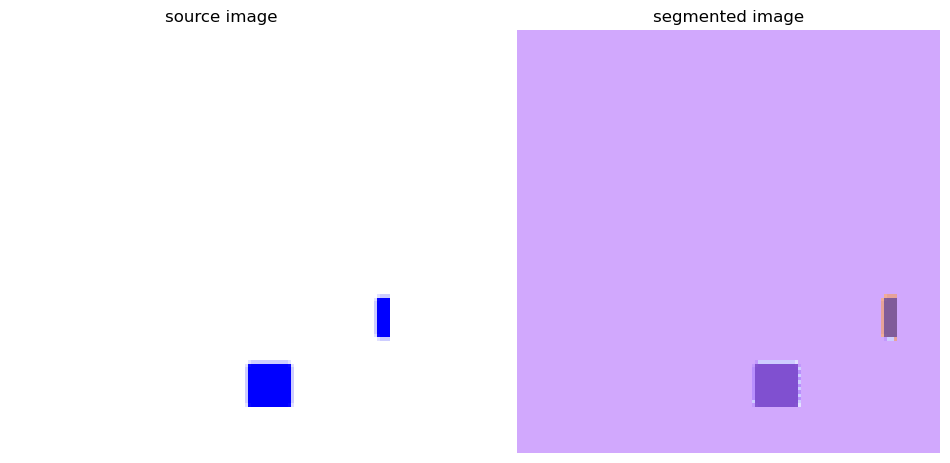

In [20]:
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections.from_sam(sam_result=sam_result)

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[image_bgr, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

### Interaction with segmentation results

In [21]:
'''masks = [
    mask['segmentation']
    for mask
    in sorted(sam_result, key=lambda x: x['area'], reverse=True)
]

sv.plot_images_grid(
    images=masks,
    grid_size=(8, int(len(masks) / 8)),
    size=(16, 16)
)'''

"masks = [\n    mask['segmentation']\n    for mask\n    in sorted(sam_result, key=lambda x: x['area'], reverse=True)\n]\n\nsv.plot_images_grid(\n    images=masks,\n    grid_size=(8, int(len(masks) / 8)),\n    size=(16, 16)\n)"

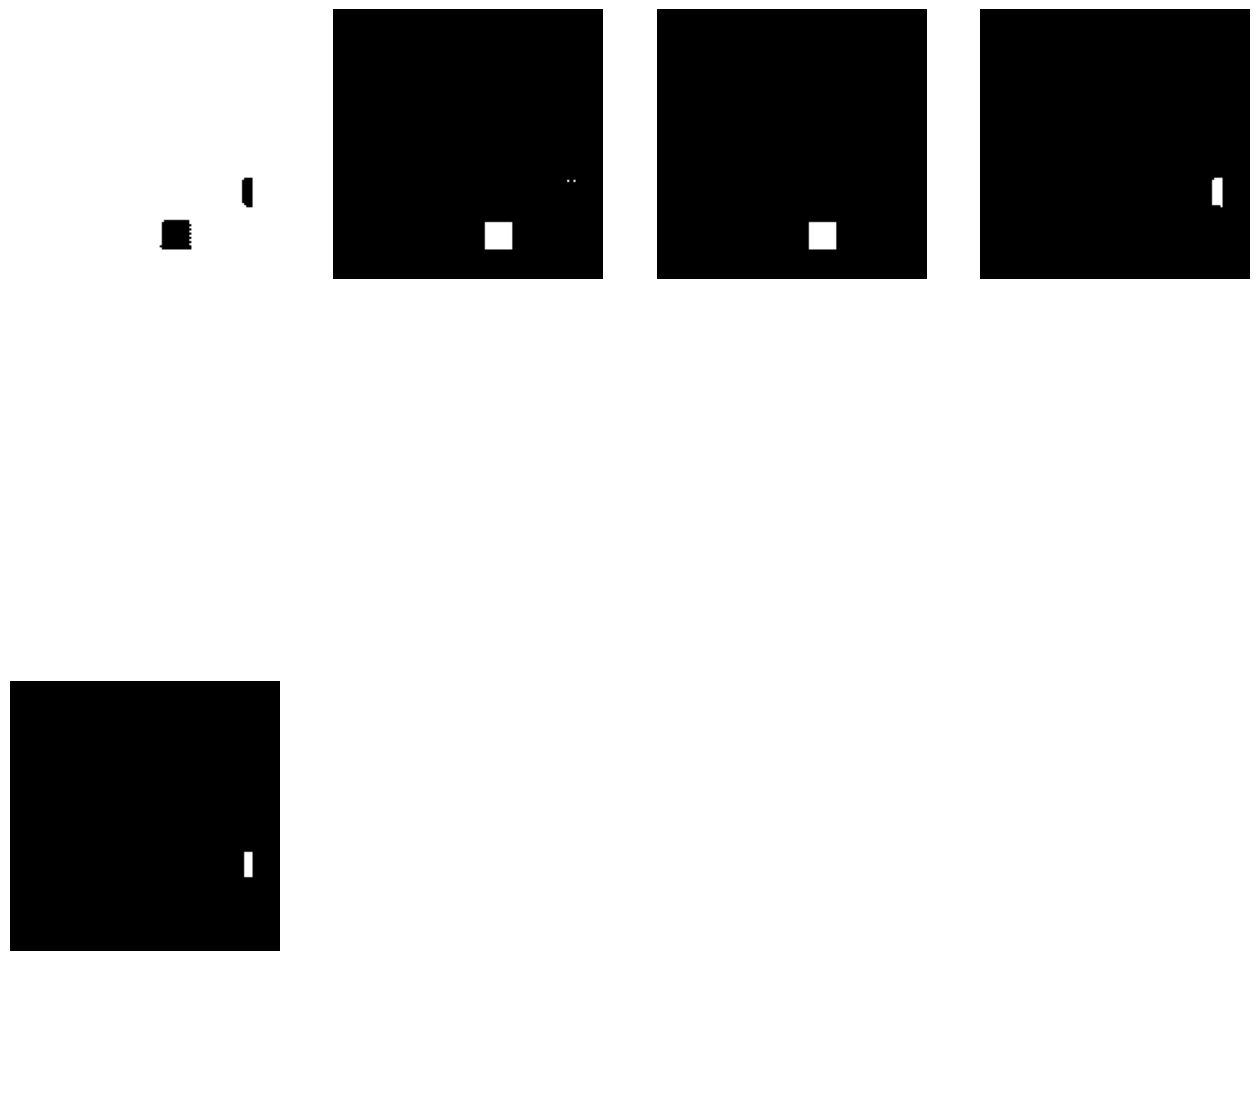

In [22]:
# Extract all segmentation masks from the SAM results
masks = [
    mask['segmentation']
    for mask in sorted(sam_result, key=lambda x: x['area'], reverse=True)
]

# Calculate grid size dynamically based on the number of masks
num_masks = len(masks)
ncols = 4  # Set a fixed number of columns (you can adjust this number)
nrows = (num_masks // ncols) + (1 if num_masks % ncols != 0 else 0)  # Calculate rows

# Plot all masks in a grid
sv.plot_images_grid(
    images=masks,
    grid_size=(nrows, ncols),
    size=(16, 16)
)

## Generate Segmentation with Bounding Box

The `SamPredictor` class provides an easy interface to the model for prompting the model. It allows the user to first set an image using the `set_image` method, which calculates the necessary image embeddings. Then, prompts can be provided via the `predict` method to efficiently predict masks from those prompts. The model can take as input both point and box prompts, as well as masks from the previous iteration of prediction.

In [23]:
mask_predictor = SamPredictor(sam)

In [24]:
'''import os

IMAGE_NAME = "dog.jpeg"
IMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)'''

'import os\n\nIMAGE_NAME = "dog.jpeg"\nIMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)'

In [25]:
import os

# Define the path for the generated Shapes dataset
dataset_dir = "./shapes_dataset/images"  # Path to your images in the Shapes dataset
image_id = 0  # Modify if you'd like to process a different image
image_file = f"shapes_{image_id}.png"  # Assuming the images are named like 'shapes_0.png', etc.
IMAGE_PATH = os.path.join(dataset_dir, image_file)

### Draw Box



In [26]:
# helper function that loads an image before adding it to the widget

import base64

def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

**NOTE:** Execute cell below and use your mouse to draw bounding box on the image 👇

In [27]:
'''IS_COLAB = True

if IS_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

from jupyter_bbox_widget import BBoxWidget

widget = BBoxWidget()
widget.image = encode_image(IMAGE_PATH)
widget'''

'IS_COLAB = True\n\nif IS_COLAB:\n    from google.colab import output\n    output.enable_custom_widget_manager()\n\nfrom jupyter_bbox_widget import BBoxWidget\n\nwidget = BBoxWidget()\nwidget.image = encode_image(IMAGE_PATH)\nwidget'

In [28]:
# Install the required packages
!pip install ipywidgets jupyter_bbox_widget

In [29]:
import ipywidgets as widgets

In [30]:
!pip install jupyterlab_widgets

In [31]:
from jupyter_bbox_widget import BBoxWidget

In [32]:
import ipywidgets as widgets
widgets.IntSlider()

IntSlider(value=0)

In [33]:
# Define the widget
widget = BBoxWidget()

# Set the image for the widget
widget.image = encode_image(IMAGE_PATH)

# Set the classes (labels) for the widget
widget.classes = ['square', 'circle']

# Display the widget
display(widget)

BBoxWidget(classes=['square', 'circle'], colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c56…

In [34]:
widget.bboxes

[]

### Generate masks with SAM

**NOTE:** `SamPredictor.predict` method takes `np.ndarray` `box` argument in `[x_min, y_min, x_max, y_max]` format. Let's reorganise your data first

In [35]:
import numpy as np

# default_box is going to be used if you will not draw any box on image above
default_box = {'x': 68, 'y': 247, 'width': 555, 'height': 678, 'label': ''}

box = widget.bboxes[0] if widget.bboxes else default_box
box = np.array([
    box['x'],
    box['y'],
    box['x'] + box['width'],
    box['y'] + box['height']
])

In [36]:
import cv2
import numpy as np
import supervision as sv

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    box=box,
    multimask_output=True
)

### Results visualisation with Supervision

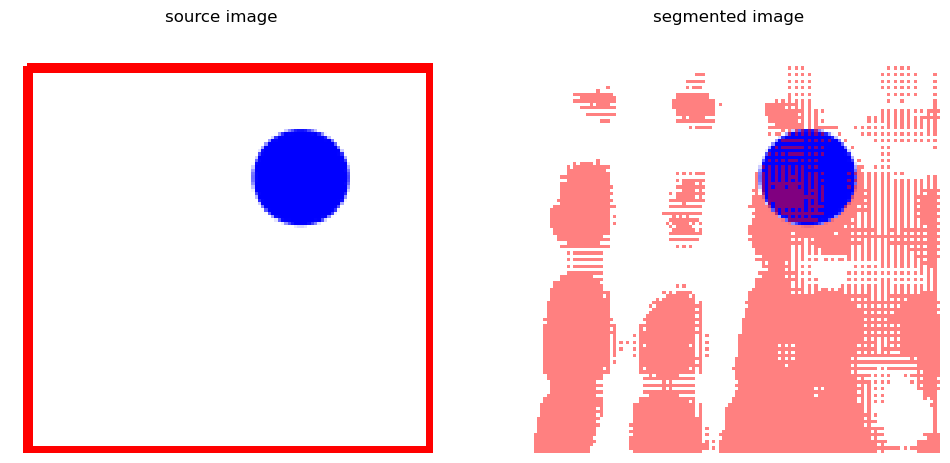

In [37]:
box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
)
detections = detections[detections.area == np.max(detections.area)]

source_image = box_annotator.annotate(scene=image_bgr.copy(), detections=detections)
segmented_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[source_image, segmented_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

### Interaction with segmentation results

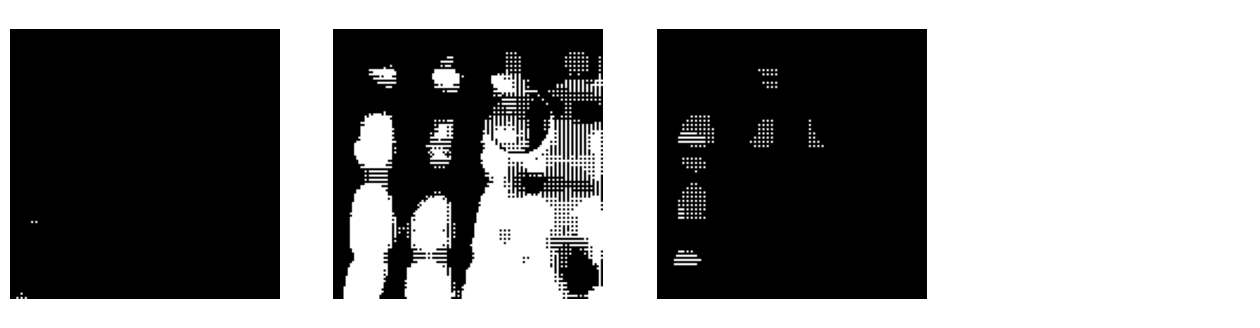

In [38]:
import supervision as v

sv.plot_images_grid(
    images=masks,
    grid_size=(1, 4),
    size=(16, 4)
)

In [39]:
# After generating the segmented image with SAM and Supervision, add this code for annotation generation

import numpy as np
import json
import cv2
import supervision as sv

# Define the path to save the annotations (update the path as needed)
annotations_output_path = "./annotations_output"

# Ensure the directory exists
os.makedirs(annotations_output_path, exist_ok=True)

# Define the image information
image_id = 0  # Image ID (modify if necessary)
image_file = f"shapes_{image_id}.png"  # Modify based on your image naming convention
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Create COCO-style annotation
annotations = []
annotation_id = 1

# Extract segmentation and bounding box details
segmentation = []
for mask in masks:
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        segmentation.append(contour.flatten().tolist())  # Flatten the contour points

# Create bounding box for each mask
for detection in detections.xyxy:
    # Ensure all coordinates are in int format (convert numpy int64 to python int)
    x_min, y_min, x_max, y_max = map(int, detection)  # Convert to regular Python ints
    bbox = [x_min, y_min, x_max - x_min, y_max - y_min]  # Bounding box [x_min, y_min, width, height]

    # Add annotation for each detected object (bounding box and segmentation)
    annotations.append({
        "id": annotation_id,
        "image_id": image_id,
        "category_id": 1,  # Change based on your categories (1 for circle, 2 for rect)
        "bbox": bbox,
        "segmentation": segmentation,  # Segmentation polygon
        "area": int(bbox[2] * bbox[3]),  # Ensure area is an integer
        "iscrowd": 0  # Indicating no crowd objects
    })
    annotation_id += 1

# COCO annotations structure
coco_data = {
    "images": [{
        "id": image_id,
        "file_name": image_file,
        "width": int(image_bgr.shape[1]),  # Ensure width is an integer
        "height": int(image_bgr.shape[0])  # Ensure height is an integer
    }],
    "annotations": annotations,
    "categories": [{
        "id": 1,
        "name": "circle",  # Modify the category names as needed
        "supercategory": "shape"
    }, {
        "id": 2,
        "name": "rect",
        "supercategory": "shape"
    }]
}

# Save the COCO annotations to a file
annotations_file_path = os.path.join(annotations_output_path, "coco_annotations.json")
with open(annotations_file_path, "w") as f:
    json.dump(coco_data, f, indent=4)

print(f"COCO annotations saved to {annotations_file_path}")

COCO annotations saved to ./annotations_output/coco_annotations.json


In [40]:
import json

# Load the COCO annotations file
annotations_file_path = './annotations_output/coco_annotations.json'

# Open and load the JSON data
with open(annotations_file_path, 'r') as f:
    coco_data = json.load(f)

# Inspecting the COCO data
print("Images in the dataset:")
print(coco_data['images'])

print("\nAnnotations:")
print(coco_data['annotations'])

print("\nCategories:")
print(coco_data['categories'])

Images in the dataset:
[{'id': 0, 'file_name': 'shapes_0.png', 'width': 128, 'height': 128}]

Annotations:
[{'id': 1, 'image_id': 0, 'category_id': 1, 'bbox': [5, 11, 122, 116], 'segmentation': [[7, 127], [5, 127], [3, 127], [5, 125], [12, 91], [10, 91], [117, 126], [59, 126], [59, 124], [57, 122], [57, 120], [108, 116], [110, 112], [108, 112], [110, 110], [108, 110], [110, 108], [108, 108], [119, 106], [112, 106], [110, 106], [108, 106], [117, 104], [112, 104], [110, 104], [108, 104], [110, 102], [29, 100], [57, 98], [35, 98], [57, 96], [35, 96], [31, 96], [57, 94], [35, 94], [33, 94], [31, 94], [57, 92], [35, 92], [44, 79, 45, 80, 43, 82, 42, 81, 40, 83, 41, 84, 38, 87, 39, 88, 38, 89, 37, 89, 37, 103, 39, 103, 40, 104, 39, 105, 38, 105, 43, 105, 44, 106, 43, 107, 38, 107, 43, 107, 44, 108, 43, 109, 38, 109, 39, 109, 40, 110, 39, 111, 37, 111, 37, 112, 36, 113, 35, 113, 35, 118, 34, 119, 35, 120, 34, 121, 35, 122, 34, 123, 34, 126, 35, 127, 55, 127, 56, 126, 57, 126, 57, 124, 56, 125

## Segment Anything in Roboflow Universe Dataset

### Utils Supporting Dataset Processing

A couple of helper functions that, unfortunately, we have to write ourselves to facilitate the processing of COCO annotations.

In [41]:
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Union, Optional
from dataclasses_json import dataclass_json
from supervision import Detections


@dataclass_json
@dataclass
class COCOCategory:
    id: int
    name: str
    supercategory: str


@dataclass_json
@dataclass
class COCOImage:
    id: int
    width: int
    height: int
    file_name: str
    #license: int
    #date_captured: str
    coco_url: Optional[str] = None
    flickr_url: Optional[str] = None


@dataclass_json
@dataclass
class COCOAnnotation:
    id: int
    image_id: int
    category_id: int
    segmentation: List[List[float]]
    area: float
    bbox: Tuple[float, float, float, float]
    iscrowd: int


#@dataclass_json
#@dataclass
#class COCOLicense:
#    id: int
#    name: str
#    url: str


@dataclass_json
@dataclass
class COCOJson:
    images: List[COCOImage]
    annotations: List[COCOAnnotation]
    categories: List[COCOCategory]
    #licenses: Optional[List[COCOLicense]] = None  # Marking licenses as optional


def load_coco_json(json_file: str) -> COCOJson:
    import json

    with open(json_file, "r") as f:
        json_data = json.load(f)

    return COCOJson.from_dict(json_data)


class COCOJsonUtility:
    @staticmethod
    def get_annotations_by_image_id(coco_data: COCOJson, image_id: int) -> List[COCOAnnotation]:
        return [annotation for annotation in coco_data.annotations if annotation.image_id == image_id]

    @staticmethod
    def get_annotations_by_image_path(coco_data: COCOJson, image_path: str) -> Optional[List[COCOAnnotation]]:
        image = COCOJsonUtility.get_image_by_path(coco_data, image_path)
        if image:
            return COCOJsonUtility.get_annotations_by_image_id(coco_data, image.id)
        else:
            return None

    @staticmethod
    def get_image_by_path(coco_data: COCOJson, image_path: str) -> Optional[COCOImage]:
        for image in coco_data.images:
            if image.file_name == image_path:
                return image
        return None

    @staticmethod
    def annotations2detections(annotations: List[COCOAnnotation]) -> Detections:
        class_id, xyxy = [], []

        for annotation in annotations:
            x_min, y_min, width, height = annotation.bbox
            class_id.append(annotation.category_id)
            xyxy.append([
                x_min,
                y_min,
                x_min + width,
                y_min + height
            ])

        return Detections(
            xyxy=np.array(xyxy, dtype=int),
            class_id=np.array(class_id, dtype=int)
        )

### Download Dataset from Roboflow

In [42]:
'''%cd {HOME}

import roboflow
from roboflow import Roboflow

roboflow.login()

rf = Roboflow()

project = rf.workspace("hashira-fhxpj").project("mri-brain-tumor")
dataset = project.version(1).download("coco")'''

'%cd {HOME}\n\nimport roboflow\nfrom roboflow import Roboflow\n\nroboflow.login()\n\nrf = Roboflow()\n\nproject = rf.workspace("hashira-fhxpj").project("mri-brain-tumor")\ndataset = project.version(1).download("coco")'

In [43]:
import os
import json
from dataclasses import dataclass
from typing import List, Tuple
from dataclasses_json import dataclass_json

# Define dataset path to COCO annotations
dataset_path = "shapes_dataset"  # No need for the full path if you are working inside the correct directory
annotations_file = os.path.join(dataset_path, "annotations", "coco_annotations.json")  # Path to annotations file

# Load COCO annotations
with open(annotations_file, "r") as f:
    coco_data = json.load(f)

In [44]:
'''import os

DATA_SET_SUBDIRECTORY = "test"
ANNOTATIONS_FILE_NAME = "_annotations.coco.json"
IMAGES_DIRECTORY_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY)
ANNOTATIONS_FILE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, ANNOTATIONS_FILE_NAME)'''

'import os\n\nDATA_SET_SUBDIRECTORY = "test"\nANNOTATIONS_FILE_NAME = "_annotations.coco.json"\nIMAGES_DIRECTORY_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY)\nANNOTATIONS_FILE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, ANNOTATIONS_FILE_NAME)'

In [45]:
import os
import json

# Specify the correct dataset directory
DATA_SET_SUBDIRECTORY = "shapes_dataset"  # Name of your dataset folder
ANNOTATIONS_FILE_NAME = "coco_annotations.json"  # Name of your annotations file

# Construct paths to the images and annotations directories
IMAGES_DIRECTORY_PATH = os.path.join("/Users/ma/Documents/samThesis/segment-anything/notebooks", DATA_SET_SUBDIRECTORY, "images")

# Path to the annotations file (COCO annotations)
ANNOTATIONS_FILE_PATH = os.path.join("/Users/ma/Documents/samThesis/segment-anything/notebooks", DATA_SET_SUBDIRECTORY, "annotations", ANNOTATIONS_FILE_NAME)

# Load the COCO annotations
with open(ANNOTATIONS_FILE_PATH, "r") as f:
    coco_data = json.load(f)

# Now you can process or visualize the dataset
print("Images directory:", IMAGES_DIRECTORY_PATH)
print("Annotations file:", ANNOTATIONS_FILE_PATH)

# Example: Display categories and images
print("Categories:", [category['name'] for category in coco_data['categories']])
print("Images:", [image['file_name'] for image in coco_data['images']])

Images directory: /Users/ma/Documents/samThesis/segment-anything/notebooks/shapes_dataset/images
Annotations file: /Users/ma/Documents/samThesis/segment-anything/notebooks/shapes_dataset/annotations/coco_annotations.json
Categories: ['circle', 'rect']
Images: ['shapes_0.png', 'shapes_1.png', 'shapes_2.png', 'shapes_3.png', 'shapes_4.png']


In [46]:
'''coco_data = load_coco_json(json_file=ANNOTATIONS_FILE_PATH)

CLASSES = [
    category.name
    for category
    in coco_data.categories
    if category.supercategory != 'none'
]

IMAGES = [
    image.file_name
    for image
    in coco_data.images
]'''

"coco_data = load_coco_json(json_file=ANNOTATIONS_FILE_PATH)\n\nCLASSES = [\n    category.name\n    for category\n    in coco_data.categories\n    if category.supercategory != 'none'\n]\n\nIMAGES = [\n    image.file_name\n    for image\n    in coco_data.images\n]"

In [47]:
import json
import os

# Define dataset path to COCO annotations
dataset_path = "/Users/ma/Documents/samThesis/segment-anything/notebooks/shapes_dataset"  # Path to your shapes dataset
annotations_file = os.path.join(dataset_path, "annotations", "coco_annotations.json")  # Path to annotations file

# Load COCO annotations
with open(annotations_file, "r") as f:
    coco_data = json.load(f)

# Extract Classes (Categories)
CLASSES = [
    category['name']  # Access 'name' from categories
    for category in coco_data['categories']  # Directly access categories from the JSON data
    if category['supercategory'] != 'none'
]

# Extract Images
IMAGES = [
    image['file_name']  # Access 'file_name' from images
    for image in coco_data['images']  # Directly access images from the JSON data
]

# Check the result
print(f"Classes: {CLASSES}")
print(f"Images: {IMAGES[:5]}")  # Show the first 5 images

Classes: ['circle', 'rect']
Images: ['shapes_0.png', 'shapes_1.png', 'shapes_2.png', 'shapes_3.png', 'shapes_4.png']


In [48]:
CLASSES

['circle', 'rect']

### Single Image Bounding Box to Mask

In [49]:
# set random seed to allow easy reproduction of the experiment

import random
random.seed(10)

In [50]:
'''EXAMPLE_IMAGE_NAME = random.choice(IMAGES)
EXAMPLE_IMAGE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, EXAMPLE_IMAGE_NAME)

# load dataset annotations
annotations = COCOJsonUtility.get_annotations_by_image_path(coco_data=coco_data, image_path=EXAMPLE_IMAGE_NAME)
ground_truth = COCOJsonUtility.annotations2detections(annotations=annotations)

# small hack - coco numerate classes from 1, model from 0 + we drop first redundant class from coco json
ground_truth.class_id = ground_truth.class_id - 1

# load image
image_bgr = cv2.imread(EXAMPLE_IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# initiate annotator
box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

# annotate ground truth
annotated_frame_ground_truth = box_annotator.annotate(scene=image_bgr.copy(), detections=ground_truth)

# run SAM inference
mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    box=ground_truth.xyxy[0],
    multimask_output=True
)

detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
)
detections = detections[detections.area == np.max(detections.area)]

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[annotated_frame_ground_truth, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)'''

"EXAMPLE_IMAGE_NAME = random.choice(IMAGES)\nEXAMPLE_IMAGE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, EXAMPLE_IMAGE_NAME)\n\n# load dataset annotations\nannotations = COCOJsonUtility.get_annotations_by_image_path(coco_data=coco_data, image_path=EXAMPLE_IMAGE_NAME)\nground_truth = COCOJsonUtility.annotations2detections(annotations=annotations)\n\n# small hack - coco numerate classes from 1, model from 0 + we drop first redundant class from coco json\nground_truth.class_id = ground_truth.class_id - 1\n\n# load image\nimage_bgr = cv2.imread(EXAMPLE_IMAGE_PATH)\nimage_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)\n\n# initiate annotator\nbox_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)\nmask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)\n\n# annotate ground truth\nannotated_frame_ground_truth = box_annotator.annotate(scene=image_bgr.copy(), detections=ground_truth)\n\n# run SAM inference\nmask_

Original Image Dimensions: 128x128 (width x height)
Processed Image Dimensions (after SAM): 128x128 (width x height)


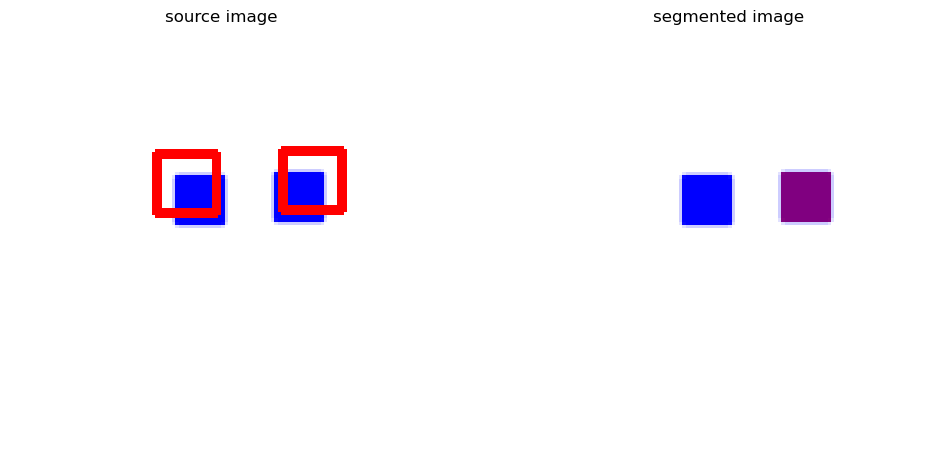

In [51]:
# Assuming coco_data is being loaded as a dictionary
with open(ANNOTATIONS_FILE_PATH, "r") as f:
    coco_data_dict = json.load(f)

# Convert the dictionary to COCOJson class instance
coco_data = COCOJson.from_dict(coco_data_dict)

# Now you can proceed with the rest of the code
EXAMPLE_IMAGE_NAME = random.choice(IMAGES)
EXAMPLE_IMAGE_PATH = os.path.join("/Users/ma/Documents/samThesis/segment-anything/notebooks/shapes_dataset/images", EXAMPLE_IMAGE_NAME)  # Adjusting to match your image directory

# Load dataset annotations (get annotations for the randomly selected image)
annotations = COCOJsonUtility.get_annotations_by_image_path(coco_data=coco_data, image_path=EXAMPLE_IMAGE_NAME)

# Convert the annotations to detections format (to match the ground_truth format for annotation)
ground_truth = COCOJsonUtility.annotations2detections(annotations=annotations)

# Adjust the class IDs (COCO starts from 1, but the model expects 0-based indexing)
ground_truth.class_id = ground_truth.class_id - 1

# Load the image from the dataset
image_bgr = cv2.imread(EXAMPLE_IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Print dimensions of the original image
print(f"Original Image Dimensions: {image_bgr.shape[1]}x{image_bgr.shape[0]} (width x height)")

# Create annotators for visualizing the bounding boxes and masks
box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

# Annotate the image with ground truth bounding boxes
annotated_frame_ground_truth = box_annotator.annotate(scene=image_bgr.copy(), detections=ground_truth)

# Run SAM inference (segment the image based on the bounding box)
mask_predictor.set_image(image_rgb)

# Print dimensions after SAM processes the image
print(f"Processed Image Dimensions (after SAM): {image_rgb.shape[1]}x{image_rgb.shape[0]} (width x height)")

masks, scores, logits = mask_predictor.predict(
    box=ground_truth.xyxy[0],  # Using the first bounding box (could be changed to support multiple boxes)
    multimask_output=True
)

# Convert the masks into detections format
detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
)

# Select the largest area detection (to avoid false positives)
detections = detections[detections.area == np.max(detections.area)]

# Annotate the image with the segmented masks
annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

# Display the original annotated image (with ground truth boxes) and the segmented image side by side
sv.plot_images_grid(
    images=[annotated_frame_ground_truth, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

# My experiment

In [1]:
import torch

# Check if MPS (Metal Performance Shaders) is available
device = torch.device("mps" if torch.backends.mps.is_built() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /Users/ma/Documents/samThesis/segment-anything/notebooks


In [3]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

In [4]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

In [5]:
!mkdir -p {HOME}/weights
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P {HOME}/weights

In [6]:
import os

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

/Users/ma/Documents/samThesis/segment-anything/notebooks/weights/sam_vit_h_4b8939.pth ; exist: True


In [7]:
!mkdir -p {HOME}/data

In [8]:
# Set up paths for saving the dataset
save_dir = "./shapes_dataset"  # Modify to your preferred path

# Generate the dataset with shapes (circle and rectangle)
!python ./shapes/run.py --save_dir {save_dir} --image_size 128 128 --num_images 5 --shapes circle rect

# Print confirmation message
print(f"✅ Shapes dataset generated and saved to {save_dir}")

Generating dataset:   0%|                                 | 0/5 [00:00<?, ?it/s]Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Generating dataset:  20%|█████                    | 1/5 [00:00<00:01,  3.81it/s]Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Generating dataset: 100%|█████████████████████████| 5/5 [00:00<00:00, 15.73it/s]
✅ Dataset and COCO annotations saved to ./shapes_dataset
✅ Shapes dataset generated and saved 

In [9]:
import json
import os

# Step 1: Set paths for the generated Shapes dataset
dataset_dir = "./shapes_dataset/images"  # Path to the generated images
annotation_dir = "./shapes_dataset/annotations"  # Path to the generated COCO annotations

# Step 2: Load COCO annotations
annotation_file = os.path.join(annotation_dir, "coco_annotations.json")

with open(annotation_file, "r") as f:
    coco_data = json.load(f)

# Step 3: Print out the structure of the COCO data to ensure it's loaded correctly
print(coco_data)

{'images': [{'id': 0, 'width': 128, 'height': 128, 'file_name': 'shapes_0.png'}, {'id': 1, 'width': 128, 'height': 128, 'file_name': 'shapes_1.png'}, {'id': 2, 'width': 128, 'height': 128, 'file_name': 'shapes_2.png'}, {'id': 3, 'width': 128, 'height': 128, 'file_name': 'shapes_3.png'}, {'id': 4, 'width': 128, 'height': 128, 'file_name': 'shapes_4.png'}], 'annotations': [{'id': 1, 'image_id': 0, 'category_id': 1, 'bbox': [45, 21, 46, 46], 'segmentation': [], 'area': 2116, 'iscrowd': 0}, {'id': 2, 'image_id': 0, 'category_id': 1, 'bbox': [53, 98, 24, 24], 'segmentation': [], 'area': 576, 'iscrowd': 0}, {'id': 3, 'image_id': 1, 'category_id': 2, 'bbox': [53, 93, 23.0, 23], 'segmentation': [], 'area': 529.0, 'iscrowd': 0}, {'id': 4, 'image_id': 2, 'category_id': 2, 'bbox': [17, 71, 18.0, 18], 'segmentation': [], 'area': 324.0, 'iscrowd': 0}, {'id': 5, 'image_id': 2, 'category_id': 1, 'bbox': [76, 102, 26, 26], 'segmentation': [], 'area': 676, 'iscrowd': 0}, {'id': 6, 'image_id': 3, 'categ

In [10]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

In [11]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

In [12]:
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Union, Optional
from dataclasses_json import dataclass_json
from supervision import Detections


@dataclass_json
@dataclass
class COCOCategory:
    id: int
    name: str
    supercategory: str


@dataclass_json
@dataclass
class COCOImage:
    id: int
    width: int
    height: int
    file_name: str
    #license: int
    #date_captured: str
    coco_url: Optional[str] = None
    flickr_url: Optional[str] = None


@dataclass_json
@dataclass
class COCOAnnotation:
    id: int
    image_id: int
    category_id: int
    segmentation: List[List[float]]
    area: float
    bbox: Tuple[float, float, float, float]
    iscrowd: int


#@dataclass_json
#@dataclass
#class COCOLicense:
#    id: int
#    name: str
#    url: str


@dataclass_json
@dataclass
class COCOJson:
    images: List[COCOImage]
    annotations: List[COCOAnnotation]
    categories: List[COCOCategory]
    #licenses: Optional[List[COCOLicense]] = None  # Marking licenses as optional


def load_coco_json(json_file: str) -> COCOJson:
    import json

    with open(json_file, "r") as f:
        json_data = json.load(f)

    return COCOJson.from_dict(json_data)


class COCOJsonUtility:
    @staticmethod
    def get_annotations_by_image_id(coco_data: COCOJson, image_id: int) -> List[COCOAnnotation]:
        return [annotation for annotation in coco_data.annotations if annotation.image_id == image_id]

    @staticmethod
    def get_annotations_by_image_path(coco_data: COCOJson, image_path: str) -> Optional[List[COCOAnnotation]]:
        image = COCOJsonUtility.get_image_by_path(coco_data, image_path)
        if image:
            return COCOJsonUtility.get_annotations_by_image_id(coco_data, image.id)
        else:
            return None

    @staticmethod
    def get_image_by_path(coco_data: COCOJson, image_path: str) -> Optional[COCOImage]:
        for image in coco_data.images:
            if image.file_name == image_path:
                return image
        return None

    @staticmethod
    def annotations2detections(annotations: List[COCOAnnotation]) -> Detections:
        class_id, xyxy = [], []

        for annotation in annotations:
            x_min, y_min, width, height = annotation.bbox
            class_id.append(annotation.category_id)
            xyxy.append([
                x_min,
                y_min,
                x_min + width,
                y_min + height
            ])

        return Detections(
            xyxy=np.array(xyxy, dtype=int),
            class_id=np.array(class_id, dtype=int)
        )

In [13]:
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Union, Optional
from dataclasses_json import dataclass_json
from supervision import Detections
import os
import json
import torch
import cv2
import matplotlib.pyplot as plt
import random
import supervision as sv

import torch
from segment_anything import sam_model_registry, SamPredictor

# Initialize the SAM model
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

# Initialize the SAM predictor
mask_predictor = SamPredictor(sam)

In [14]:
# Define dataset path to COCO annotations
dataset_path = "shapes_dataset"
annotations_file = os.path.join(dataset_path, "annotations", "coco_annotations.json")

# Load COCO annotations
with open(annotations_file, "r") as f:
    coco_data = json.load(f)

# Show the loaded categories and images
print("Categories:", [category['name'] for category in coco_data['categories']])
print("Images:", [image['file_name'] for image in coco_data['images']])

Categories: ['circle', 'rect']
Images: ['shapes_0.png', 'shapes_1.png', 'shapes_2.png', 'shapes_3.png', 'shapes_4.png']


In [15]:
# Set random seed for reproducibility
random.seed(10)

Original Image Dimensions: 128x128 (width x height)
Processed Image Dimensions (after SAM): 128x128 (width x height)
Processing bounding box 1: [45 21 91 67]


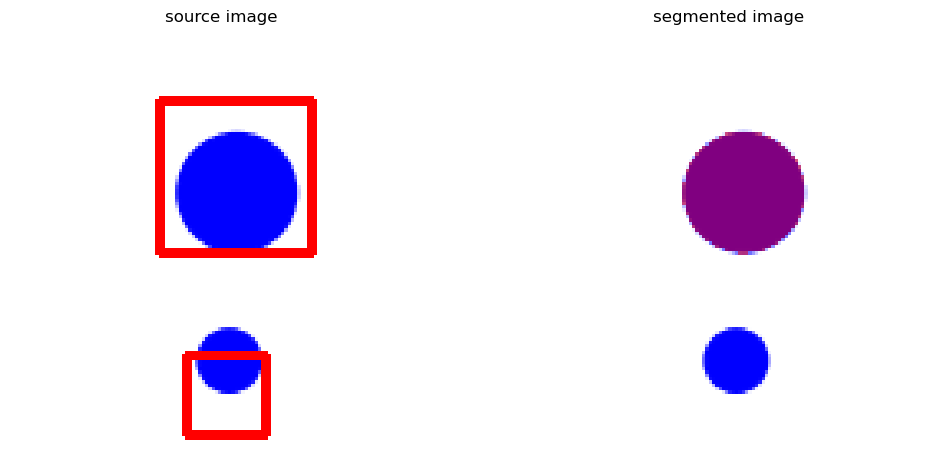

Processing bounding box 2: [ 53  98  77 122]


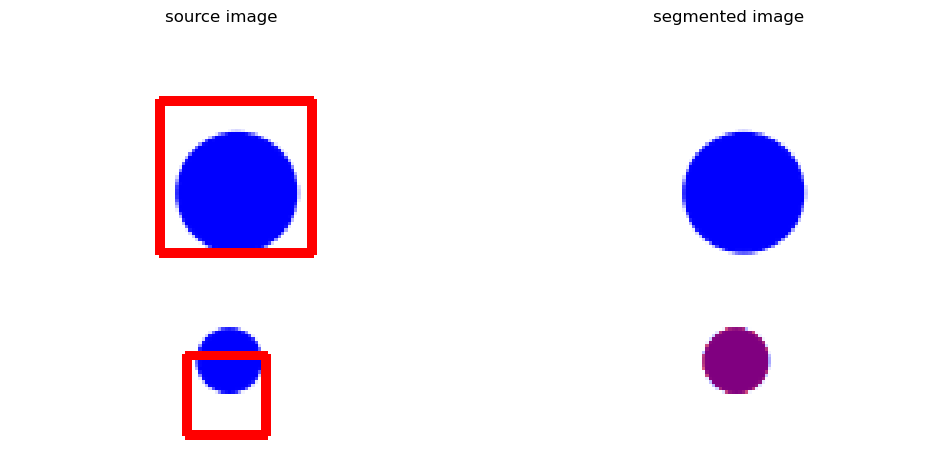

Original Image Dimensions: 128x128 (width x height)
Processed Image Dimensions (after SAM): 128x128 (width x height)
Processing bounding box 1: [ 53  93  76 116]


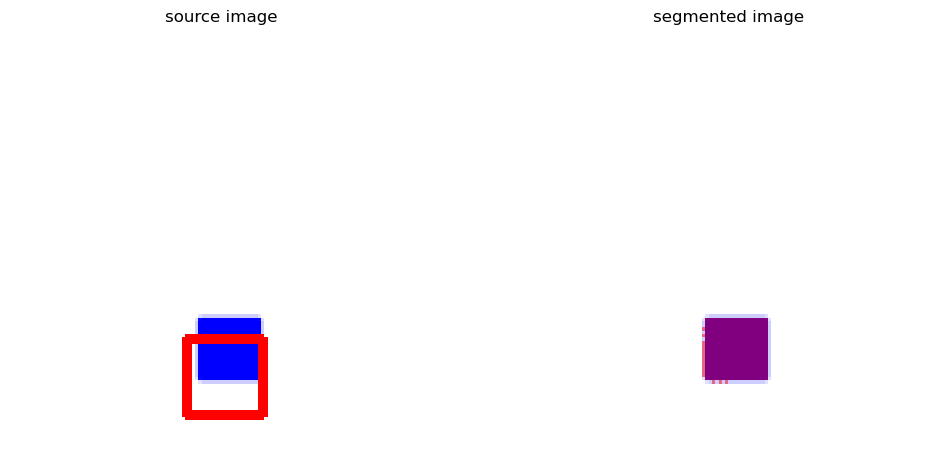

Original Image Dimensions: 128x128 (width x height)
Processed Image Dimensions (after SAM): 128x128 (width x height)
Processing bounding box 1: [17 71 35 89]


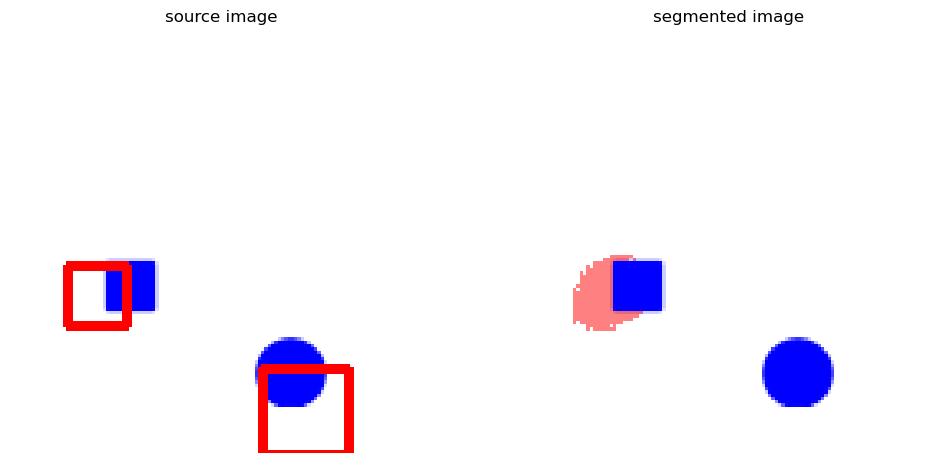

Processing bounding box 2: [ 76 102 102 128]


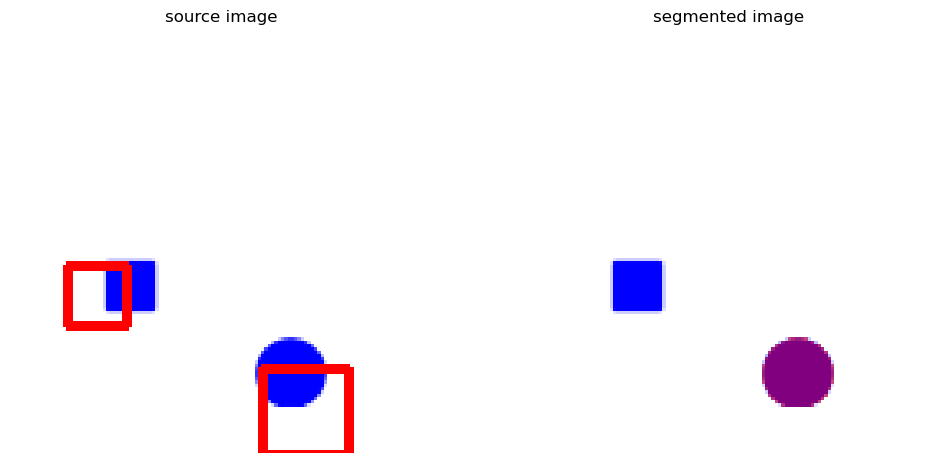

Original Image Dimensions: 128x128 (width x height)
Processed Image Dimensions (after SAM): 128x128 (width x height)
Processing bounding box 1: [ 63  54 103  94]


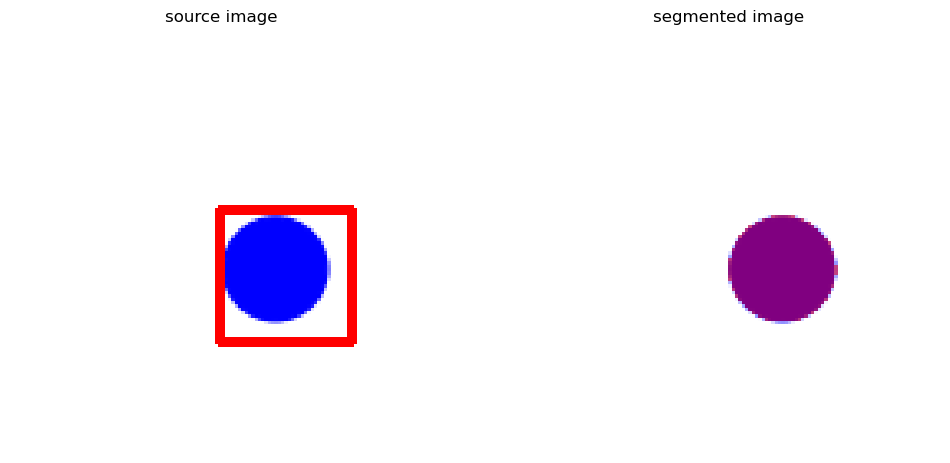

Original Image Dimensions: 128x128 (width x height)
Processed Image Dimensions (after SAM): 128x128 (width x height)
Processing bounding box 1: [ 77  37 101  61]


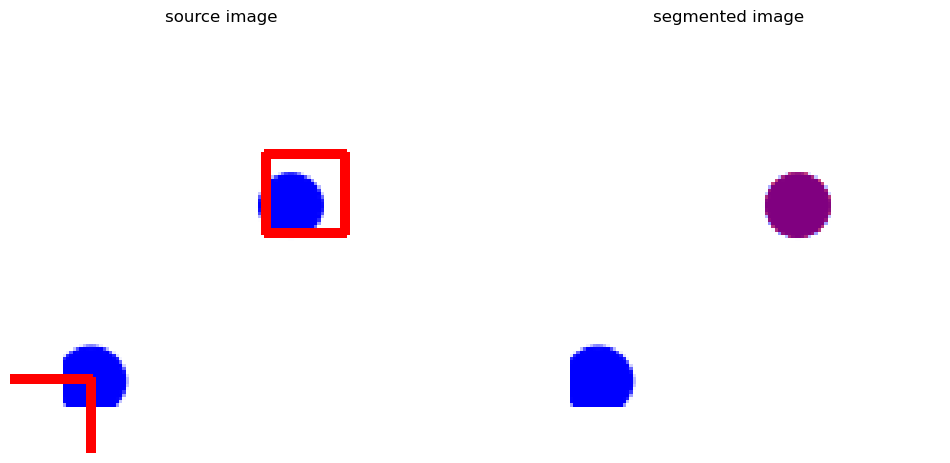

Processing bounding box 2: [ -2 105  24 131]


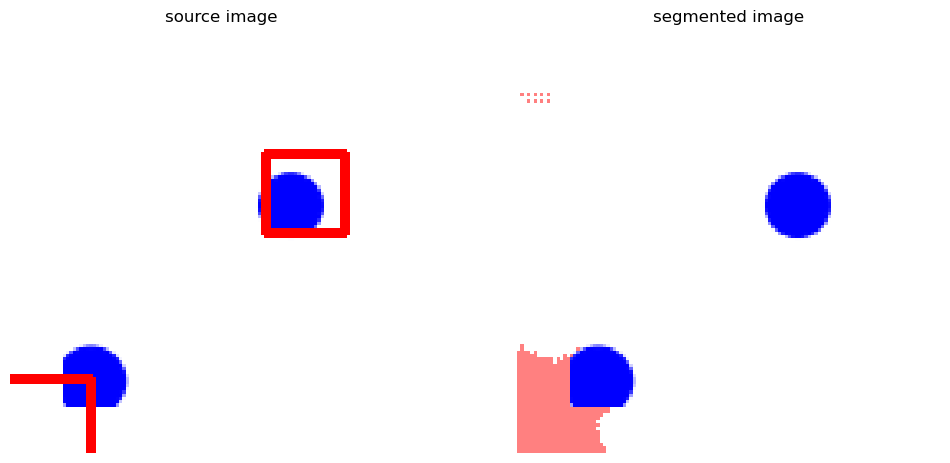

In [16]:
# Load COCO annotations into COCOJson instance
with open(annotations_file, "r") as f:
    coco_data_dict = json.load(f)
coco_data = COCOJson.from_dict(coco_data_dict)

# Iterate over the images as "epochs"
for img_info in coco_data.images:
    EXAMPLE_IMAGE_NAME = img_info.file_name
    EXAMPLE_IMAGE_PATH = os.path.join("/Users/ma/Documents/samThesis/segment-anything/notebooks/shapes_dataset/images", EXAMPLE_IMAGE_NAME)

    # Load dataset annotations (get annotations for the current image)
    annotations = COCOJsonUtility.get_annotations_by_image_path(coco_data=coco_data, image_path=EXAMPLE_IMAGE_NAME)

    # Convert the annotations to detections format
    ground_truth = COCOJsonUtility.annotations2detections(annotations=annotations)

    # Adjust the class IDs (COCO starts from 1, but the model expects 0-based indexing)
    ground_truth.class_id = ground_truth.class_id - 1

    # Load the image from the dataset
    image_bgr = cv2.imread(EXAMPLE_IMAGE_PATH)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # Print original dimensions before SAM
    print(f"Original Image Dimensions: {image_bgr.shape[1]}x{image_bgr.shape[0]} (width x height)")

    # Create annotators for visualizing the bounding boxes and masks
    box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
    mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

    # Annotate the image with ground truth bounding boxes
    annotated_frame_ground_truth = box_annotator.annotate(scene=image_bgr.copy(), detections=ground_truth)

    # Run SAM inference (segment the image based on the bounding box)
    mask_predictor.set_image(image_rgb)

    # Print processed dimensions after SAM
    print(f"Processed Image Dimensions (after SAM): {image_rgb.shape[1]}x{image_rgb.shape[0]} (width x height)")

    # Process each bounding box dynamically
    for idx, box in enumerate(ground_truth.xyxy):
        print(f"Processing bounding box {idx + 1}: {box}")  # Print bounding box coordinates

        masks, scores, logits = mask_predictor.predict(
            box=box,  # Using the current bounding box in the loop
            multimask_output=True
        )

        # Convert the masks into detections format
        detections = sv.Detections(
            xyxy=sv.mask_to_xyxy(masks=masks),
            mask=masks
        )

        # Select the largest area detection (to avoid false positives)
        detections = detections[detections.area == np.max(detections.area)]

        # Annotate the image with the segmented masks
        annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

        # Display the original annotated image (with ground truth boxes) and the segmented image side by side
        sv.plot_images_grid(
            images=[annotated_frame_ground_truth, annotated_image],
            grid_size=(1, 2),
            titles=['source image', 'segmented image']
        )

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.